In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.9 MB/s eta 0:00:00


In [33]:
import gensim.downloader as api
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
print(list(api.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [ ]:
# download the embeddings
embeddings = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
# find the most similar words to king
embeddings.most_similar('king')

[('prince', 0.8236179351806641),
 ('queen', 0.7839043140411377),
 ('ii', 0.7746230363845825),
 ('emperor', 0.7736247777938843),
 ('son', 0.766719400882721),
 ('uncle', 0.7627150416374207),
 ('kingdom', 0.7542160749435425),
 ('throne', 0.7539913654327393),
 ('brother', 0.7492411136627197),
 ('ruler', 0.7434253692626953)]

In [ ]:
# find the most similar to python
embeddings.most_similar('python')

[('reticulated', 0.6916365623474121),
 ('spamalot', 0.6635736227035522),
 ('php', 0.6414496898651123),
 ('owl', 0.6301496028900146),
 ('mouse', 0.6275478601455688),
 ('reticulatus', 0.6274471282958984),
 ('perl', 0.6267575025558472),
 ('monkey', 0.6207211017608643),
 ('monty', 0.60793536901474),
 ('scripting', 0.6041731834411621)]

In [ ]:
# find the most similar words to king + woman - man (queen)
embeddings.most_similar(positive=['king', 'woman'], negative=['man'])

[('queen', 0.8523604273796082),
 ('throne', 0.7664334177970886),
 ('prince', 0.7592144012451172),
 ('daughter', 0.7473883628845215),
 ('elizabeth', 0.7460219860076904),
 ('princess', 0.7424570322036743),
 ('kingdom', 0.7337412238121033),
 ('monarch', 0.721449077129364),
 ('eldest', 0.7184861898422241),
 ('widow', 0.7099431157112122)]

In [ ]:
embeddings.most_similar(positive=['paris', 'japan'], negative=['france'])

[('tokyo', 0.9234451055526733),
 ('shanghai', 0.8370239734649658),
 ('japanese', 0.7904196977615356),
 ('osaka', 0.7831287384033203),
 ('beijing', 0.7479599714279175),
 ('seoul', 0.7326474785804749),
 ('kong', 0.7133268713951111),
 ('hong', 0.7057299613952637),
 ('taipei', 0.701820969581604),
 ('singapore', 0.7004526257514954)]

In [12]:
embeddings.most_similar(positive=['triangle', 'four'], negative=['three'])

[('outer', 0.7057375907897949),
 ('separates', 0.6942605972290039),
 ('bordered', 0.6874277591705322),
 ('ring', 0.6740061640739441),
 ('shaped', 0.668965220451355),
 ('rings', 0.6589148044586182),
 ('divides', 0.6487187743186951),
 ('encompassing', 0.6448262929916382),
 ('axis', 0.6396350860595703),
 ('triangular', 0.6379765272140503)]

In [30]:
# Create word lists
animals = ['snake','dog', 'elephant', 'ostrich', 'cicada']
countries = ['armenia', 'germany', 'finland', 'mongolia', 'botswana']
colors = ['red', 'green', 'purple', 'orange', 'blue']
sports = ['football', 'chess', 'swimming', 'baseball', 'polo']

all_words = animals + countries + colors + sports

In [31]:
# Get the 50 component vectors for every word
all_words_vectors = [embeddings[word] for word in all_words]

In [42]:
# Reduce each word vector from 50 -> 2 components
reduced = PCA(n_components=2).fit_transform(all_words_vectors)

In [43]:
reduced

array([[-2.28642348, -2.08735196],
       [-2.3678629 , -0.5872217 ],
       [-1.47252997, -1.83478861],
       [-1.25619563, -2.27902522],
       [-0.39850311, -3.05667426],
       [ 4.16494289, -0.72302756],
       [ 3.3572375 ,  0.98167343],
       [ 3.66677685,  0.13315943],
       [ 2.69912151, -1.9785694 ],
       [ 2.12367463, -2.22136059],
       [-1.86714509,  1.22166332],
       [-2.04936433,  0.91699255],
       [-2.48498262,  0.17821809],
       [-1.57697651,  0.57112419],
       [-2.55179881,  1.2101514 ],
       [ 0.97932394,  3.46925262],
       [ 1.79300147,  1.40748713],
       [-0.21310547,  0.88933064],
       [-0.26629498,  3.02582881],
       [ 0.00710412,  0.7631377 ]])

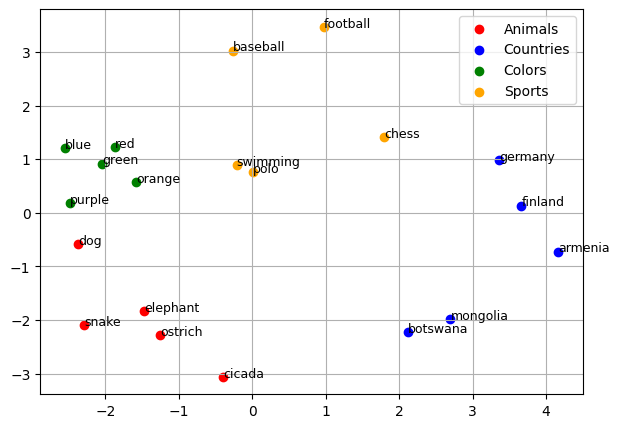

In [45]:
# Plot the results
plt.figure(figsize=(7, 5))
categories = [('Animals', animals, 'red'), ('Countries', countries, 'blue'),
              ('Colors', colors, 'green'), ('Sports', sports, 'orange')]
for cat_name, words, color in categories:
    indices = [all_words.index(w) for w in words]
    plt.scatter(reduced[indices, 0], reduced[indices, 1], color=color, label=cat_name)
    for i in indices:
        plt.annotate(all_words[i], (reduced[i, 0], reduced[i, 1]), fontsize=9)
plt.grid()
plt.legend()
plt.show()